# 280K VAE Complete Training Pipeline

This notebook implements the full VAE training pipeline on the 280K deduplicated dataset, utilizing Kaggle multi-GPU environments.


## 1. Environment & Multi-GPU Setup


In [2]:
import os
import json
import time
import random
import platform
import hashlib
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("GPUs detected:", len(tf.config.list_physical_devices("GPU")))

# Enable multi-GPU strategy
strategy = tf.distribute.MirroredStrategy()
print("Number of replicas in sync:", strategy.num_replicas_in_sync)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DIR = "/kaggle/working/VAE_280K"
DIRS = {
    "base": BASE_DIR,
    "checkpoints": os.path.join(BASE_DIR, "checkpoints"),
    "logs": os.path.join(BASE_DIR, "logs"),
    "config": os.path.join(BASE_DIR, "config")
}
for path in DIRS.values():
    os.makedirs(path, exist_ok=True)
print("Output directories created at:", BASE_DIR)


TensorFlow version: 2.20.0
GPUs detected: 2
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of replicas in sync: 2
Output directories created at: /kaggle/working/VAE_280K


I0000 00:00:1787474198.029948      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787474198.032718      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 2. Load Dataset & Preprocessing


In [3]:
!pip install -q datasets
from datasets import load_dataset
dataset = load_dataset("evilsocket/alucard-sprites")
train_data = dataset["train"]
print(f"Total raw images: {len(train_data):,}")


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/195M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/195M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/196M [00:00<?, ?B/s]

data/train-00003-of-00006.parquet:   0%|          | 0.00/197M [00:00<?, ?B/s]

data/train-00004-of-00006.parquet:   0%|          | 0.00/195M [00:00<?, ?B/s]

data/train-00005-of-00006.parquet:   0%|          | 0.00/194M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/312550 [00:00<?, ? examples/s]

Total raw images: 312,550


### Deduplication


In [4]:
UNIQUE_INDICES_PATH = os.path.join(DIRS["config"], "unique_indices.json")

def image_hash(image):
    pixels = np.asarray(image.convert("RGBA"), dtype=np.uint8)
    return hashlib.sha256(pixels.tobytes()).hexdigest()

if os.path.exists(UNIQUE_INDICES_PATH):
    with open(UNIQUE_INDICES_PATH, "r") as f:
        unique_indices = json.load(f)["unique_indices"]
    print(f"Loaded existing unique indices: {len(unique_indices):,}")
else:
    print("Starting exact SHA256 deduplication (this may take a few minutes)...")
    unique_indices = []
    seen_hashes = set()
    for i in range(len(train_data)):
        h = image_hash(train_data[i]["image"])
        if h not in seen_hashes:
            seen_hashes.add(h)
            unique_indices.append(i)
        if (i+1) % 50_000 == 0:
            print(f"Processed {i+1:,} images...")
            
    with open(UNIQUE_INDICES_PATH, "w") as f:
        json.dump({"unique_indices": unique_indices}, f)
    print(f"Deduplication complete. Unique images: {len(unique_indices):,}")


Starting exact SHA256 deduplication (this may take a few minutes)...
Processed 50,000 images...
Processed 100,000 images...
Processed 150,000 images...
Processed 200,000 images...
Processed 250,000 images...
Processed 300,000 images...
Deduplication complete. Unique images: 282,511


### Deterministic Split


In [5]:
SHUFFLED_INDICES_PATH = os.path.join(DIRS["config"], "shuffled_indices.json")

if os.path.exists(SHUFFLED_INDICES_PATH):
    with open(SHUFFLED_INDICES_PATH, "r") as f:
        shuffled_indices = json.load(f)["shuffled"]
else:
    shuffled_indices = np.array(unique_indices, dtype=np.int64)
    rng = np.random.default_rng(SEED)
    rng.shuffle(shuffled_indices)
    shuffled_indices = shuffled_indices.tolist()
    with open(SHUFFLED_INDICES_PATH, "w") as f:
        json.dump({"shuffled": shuffled_indices}, f)

TOTAL_CLEAN = len(shuffled_indices)
TRAIN_SIZE = int(round(TOTAL_CLEAN * 0.90))
VAL_SIZE = int(round(TOTAL_CLEAN * 0.05))
TEST_SIZE = TOTAL_CLEAN - TRAIN_SIZE - VAL_SIZE

train_indices = shuffled_indices[:TRAIN_SIZE]
val_indices = shuffled_indices[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]
test_indices = shuffled_indices[TRAIN_SIZE + VAL_SIZE:]

print(f"Train: {len(train_indices):,}")
print(f"Validation: {len(val_indices):,}")
print(f"Test: {len(test_indices):,}")


Train: 254,260
Validation: 14,126
Test: 14,125


## 3. Lazy tf.data Pipeline


In [6]:
def preprocess_image(image):
    image = image.convert("RGBA")
    image = np.asarray(image, dtype=np.float32) / 255.0
    return image

def image_generator(indices):
    for index in indices:
        image = train_data[int(index)]["image"]
        image = preprocess_image(image)
        yield image, image

OUTPUT_SIGNATURE = (
    tf.TensorSpec(shape=(128, 128, 4), dtype=tf.float32),
    tf.TensorSpec(shape=(128, 128, 4), dtype=tf.float32)
)

train_raw = tf.data.Dataset.from_generator(lambda: image_generator(train_indices), output_signature=OUTPUT_SIGNATURE)
val_raw = tf.data.Dataset.from_generator(lambda: image_generator(val_indices), output_signature=OUTPUT_SIGNATURE)
test_raw = tf.data.Dataset.from_generator(lambda: image_generator(test_indices), output_signature=OUTPUT_SIGNATURE)

BATCH_SIZE_PER_GPU = 32
GLOBAL_BATCH_SIZE = BATCH_SIZE_PER_GPU * strategy.num_replicas_in_sync
print(f"Global Batch Size: {GLOBAL_BATCH_SIZE}")

train_ds = train_raw.shuffle(2048, seed=SEED).batch(GLOBAL_BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)
val_ds = val_raw.batch(GLOBAL_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_raw.batch(GLOBAL_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Load some test originals for evaluation later
test_originals = []
for images, _ in test_ds.take(2): # Take enough for 64 samples
    test_originals.append(images.numpy())
test_originals = np.concatenate(test_originals, axis=0)


Global Batch Size: 64


## 4. VAE Architecture


In [7]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=0.001, **kwargs):
        self.beta = beta
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        _, _, z = self.encoder(inputs)
        return self.decoder(z)

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x)
            reconstruction = self.decoder(z)
            # Use raw math to bypass Kaggle keras version quirks
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(x - reconstruction), axis=(1, 2, 3))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = self.beta * tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
            
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        x, _ = data
        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(x - reconstruction), axis=(1, 2, 3))
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = self.beta * tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }



In [8]:
with strategy.scope():
    latent_dim = 256

    # Define Sampling layer inside strategy scope for self-containment
    class Sampling(layers.Layer):
        def call(self, inputs):
            z_mean, z_log_var = inputs
            batch = tf.shape(z_mean)[0]
            dim = tf.shape(z_mean)[1]
            epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
            return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    # Define VAE Model inside strategy scope for self-containment
    class VAE(keras.Model):
        def __init__(self, encoder, decoder, beta=0.001, **kwargs):
            self.beta = beta
            super(VAE, self).__init__(**kwargs)
            self.encoder = encoder
            self.decoder = decoder
            self.total_loss_tracker = keras.metrics.Mean(name="loss")
            self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
            self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

        @property
        def metrics(self):
            return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

        def call(self, inputs):
            _, _, z = self.encoder(inputs)
            return self.decoder(z)

        def train_step(self, data):
            x, _ = data
            with tf.GradientTape() as tape:
                z_mean, z_log_var, z = self.encoder(x)
                reconstruction = self.decoder(z)
                reconstruction_loss = tf.reduce_mean(
                    tf.reduce_sum(tf.square(x - reconstruction), axis=(1, 2, 3))
                )
                kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
                kl_loss = self.beta * tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
                total_loss = reconstruction_loss + kl_loss
                
            grads = tape.gradient(total_loss, self.trainable_weights)
            self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
            self.total_loss_tracker.update_state(total_loss)
            self.reconstruction_loss_tracker.update_state(reconstruction_loss)
            self.kl_loss_tracker.update_state(kl_loss)
            return {
                "loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.reconstruction_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result(),
            }

        def test_step(self, data):
            x, _ = data
            z_mean, z_log_var, z = self.encoder(x)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(x - reconstruction), axis=(1, 2, 3))
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = self.beta * tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
            self.total_loss_tracker.update_state(total_loss)
            self.reconstruction_loss_tracker.update_state(reconstruction_loss)
            self.kl_loss_tracker.update_state(kl_loss)
            return {
                "loss": self.total_loss_tracker.result(),
                "reconstruction_loss": self.reconstruction_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result(),
            }

    # Encoder
    encoder_inputs = keras.Input(shape=(128, 128, 4))
    x = layers.Conv2D(32, 3, activation="relu", padding="same", strides=2)(encoder_inputs)
    x = layers.Conv2D(64, 3, activation="relu", padding="same", strides=2)(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same", strides=2)(x)
    x = layers.Conv2D(256, 3, activation="relu", padding="same", strides=2)(x)
    x = layers.Flatten()(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

    # Decoder
    latent_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(8 * 8 * 256, activation="relu")(latent_inputs)
    x = layers.Reshape((8, 8, 256))(x)
    x = layers.Conv2DTranspose(128, 4, activation="relu", padding="same", strides=2)(x)
    x = layers.Conv2DTranspose(64, 4, activation="relu", padding="same", strides=2)(x)
    x = layers.Conv2DTranspose(32, 4, activation="relu", padding="same", strides=2)(x)
    decoder_outputs = layers.Conv2DTranspose(4, 4, activation="sigmoid", padding="same", strides=2)(x)
    decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

    # Full VAE
    vae = VAE(encoder, decoder)
    vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
    
encoder.summary()
decoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      1,184 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     73,856 │ conv2d_1[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 256) │    295,168 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16384)     │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 256)       │  4,194,560 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 256)       │  4,194,560 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 256)       │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,777,824 (33.48 MB)

 Trainable params: 8,777,824 (33.48 MB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16384)          │     4,210,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 32)     │        32,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 128, 128, 4)    │         2,052 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,901,092 (18.70 MB)

 Trainable params: 4,901,092 (18.70 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
## 5. Training


In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    # Save weights at the end of every epoch so we can resume if interrupted
    keras.callbacks.ModelCheckpoint(filepath=os.path.join(DIRS["checkpoints"], "latest.weights.h5"), save_weights_only=True),
    keras.callbacks.ModelCheckpoint(filepath=os.path.join(DIRS["checkpoints"], "best.weights.h5"), save_best_only=True, monitor="val_loss", save_weights_only=True),
    # Crucial: Use append=True so we don't overwrite previous history when resuming
    keras.callbacks.CSVLogger(os.path.join(DIRS["logs"], "training_log.csv"), append=True)
]

# Build explicitly so checkpointing works
vae.build((None, 128, 128, 4))

EPOCHS = 50
STEPS_PER_EPOCH = len(train_indices) // GLOBAL_BATCH_SIZE

# --- RESUME LOGIC ---
initial_epoch = 0
latest_checkpoint = os.path.join(DIRS["checkpoints"], "latest.weights.h5")
log_path = os.path.join(DIRS["logs"], "training_log.csv")

if os.path.exists(latest_checkpoint):
    try:
        print(f"Found existing checkpoint at {latest_checkpoint}. Loading weights to resume...")
        vae.load_weights(latest_checkpoint)
        
        # Read the log CSV to see what epoch we were on
        if os.path.exists(log_path):
            import pandas as pd
            df = pd.read_csv(log_path)
            if len(df) > 0:
                if 'epoch' in df.columns:
                    initial_epoch = int(df['epoch'].iloc[-1]) + 1
                else:
                    initial_epoch = len(df)
                print(f"Resuming training from epoch {initial_epoch}...")
    except Exception as e:
        print(f"Could not load checkpoint, starting from scratch. Error: {e}")

# Train VAE
history = vae.fit(
    train_ds,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    initial_epoch=initial_epoch
)

# Save final weights and full models for the encoder and decoder
print("Saving final weights and models to working directory...")
encoder.save_weights(os.path.join(BASE_DIR, "encoder_280k_final.weights.h5"))
decoder.save_weights(os.path.join(BASE_DIR, "decoder_280k_final.weights.h5"))
encoder.save(os.path.join(BASE_DIR, "encoder_280k_final.keras"))
decoder.save(os.path.join(BASE_DIR, "decoder_280k_final.keras"))
print("Final weights and models saved successfully!")


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


3972/3972 ━━━━━━━━━━━━━━━━━━━━ 343s 84ms/step - kl_loss: 2.0704 - loss: 1031.3903 - reconstruction_loss: 1029.3192 - val_kl_loss: 1.8576 - val_loss: 531.8643 - val_reconstruction_loss: 530.0067
Epoch 2/50
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - kl_loss: 0.0000e+00 - loss: 0.0000e+00 - reconstruction_loss: 0.0000e+00 - val_kl_loss: 1.8576 - val_loss: 532.3026 - val_reconstruction_loss: 530.4450
Epoch 3/50
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 352s 88ms/step - kl_loss: 1.6045 - loss: 454.4450 - reconstruction_loss: 452.8402 - val_kl_loss: 1.4925 - val_loss: 401.8576 - val_reconstruction_loss: 400.3651
Epoch 4/50
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - kl_loss: 0.0000e+00 - loss: 0.0000e+00 - reconstruction_loss: 0.0000e+00 - val_kl_loss: 1.4925 - val_loss: 401.8403 - val_reconstruction_loss: 400.3478
Epoch 5/50
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 338s 84ms/step - kl_loss: 1.4350 - loss: 367.7516 - reconstruction_loss: 366.3168 - val_kl_loss: 1.3844 - val_loss: 351.8842 - val_reconstructi

## 6. Evaluation & Generation


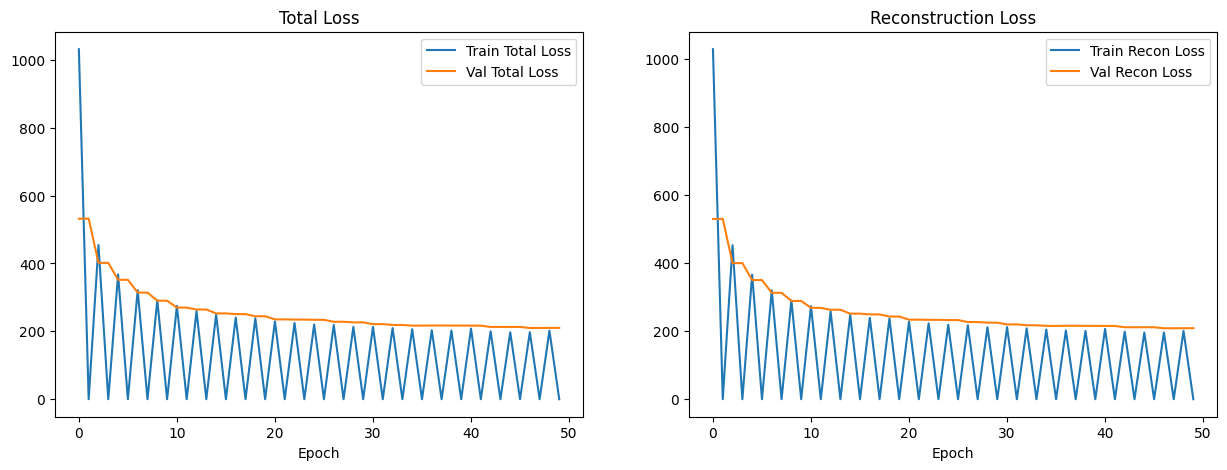

In [12]:
# Plot Training History
hist = pd.read_csv(os.path.join(DIRS["logs"], "training_log.csv"))

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(hist['loss'], label='Train Total Loss')
plt.plot(hist['val_loss'], label='Val Total Loss')
plt.title('Total Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist['reconstruction_loss'], label='Train Recon Loss')
plt.plot(hist['val_reconstruction_loss'], label='Val Recon Loss')
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')
plt.legend()
plt.savefig(os.path.join(BASE_DIR, "loss_plot.png"), bbox_inches='tight')
plt.show()


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step


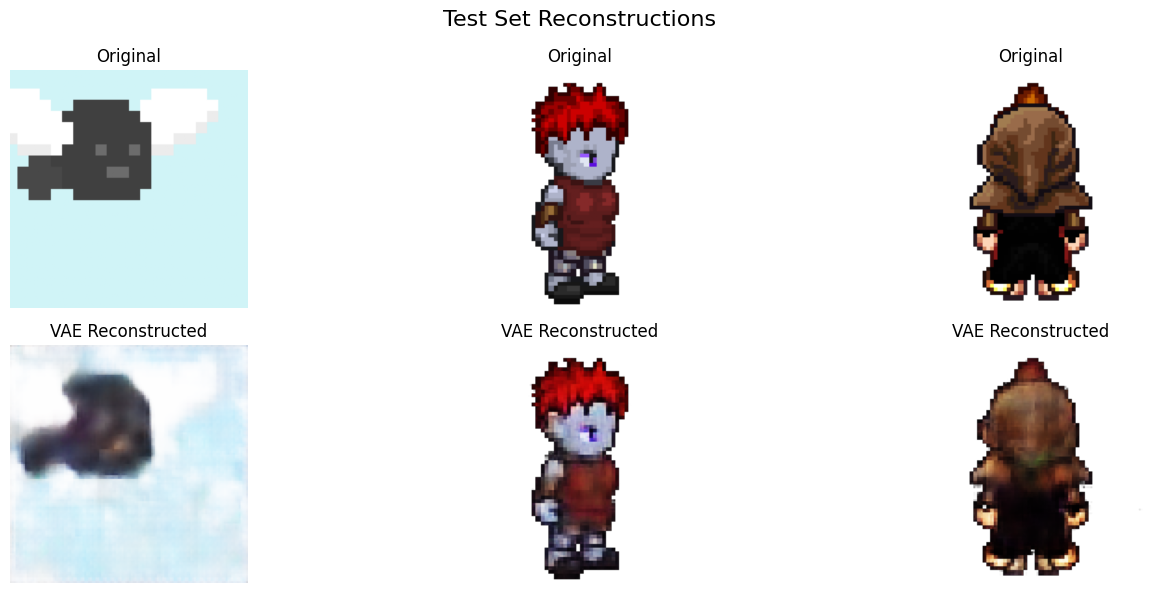

In [13]:
# Visual Reconstruction on Unseen Test Samples
random_indices = random.sample(range(len(test_originals)), 3)
test_reconstructions = vae.predict(test_originals)

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for i, idx in enumerate(random_indices):
    axes[0, i].imshow(test_originals[idx])
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")
    axes[1, i].imshow(test_reconstructions[idx])
    axes[1, i].set_title("VAE Reconstructed")
    axes[1, i].axis("off")

plt.suptitle("Test Set Reconstructions", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "reconstruction_samples.png"), bbox_inches='tight')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step


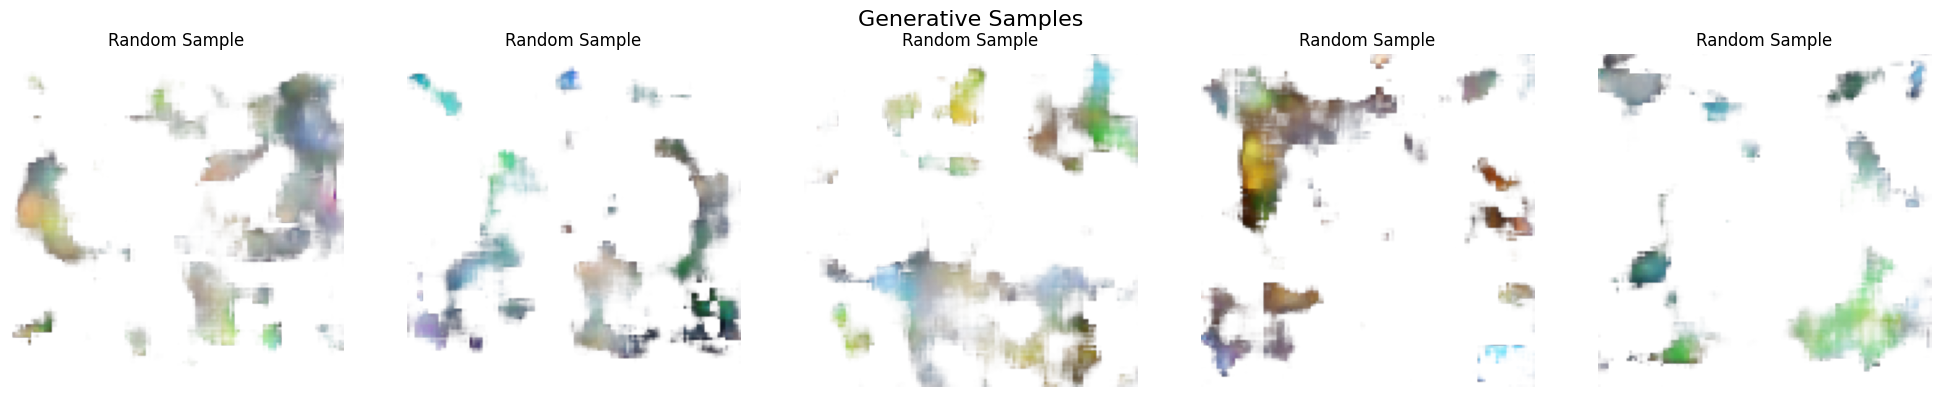

In [14]:
# Generative Samples from Random Noise
z_sample = np.random.normal(size=(5, latent_dim))
generated_images = decoder.predict(z_sample)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    axes[i].imshow(generated_images[i])
    axes[i].set_title("Random Sample")
    axes[i].axis("off")

plt.suptitle("Generative Samples", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "generative_samples.png"), bbox_inches='tight')
plt.show()


## 6.5. VAE v2 Local Variant Evaluation (Prior-Scaled)
Following our architectural validation on the 10K subset, we run a quantitative validation and visualization on 12 random sprites from the test set using the global-prior-scale fix (`scale = 1.2`). This confirms that visual variation is successfully achieved along a fixed latent direction across the full 280K dataset. The resulting comparison plot and MSE analysis table are exported.

Running Generalization Check on 12 Random Test Sprites...


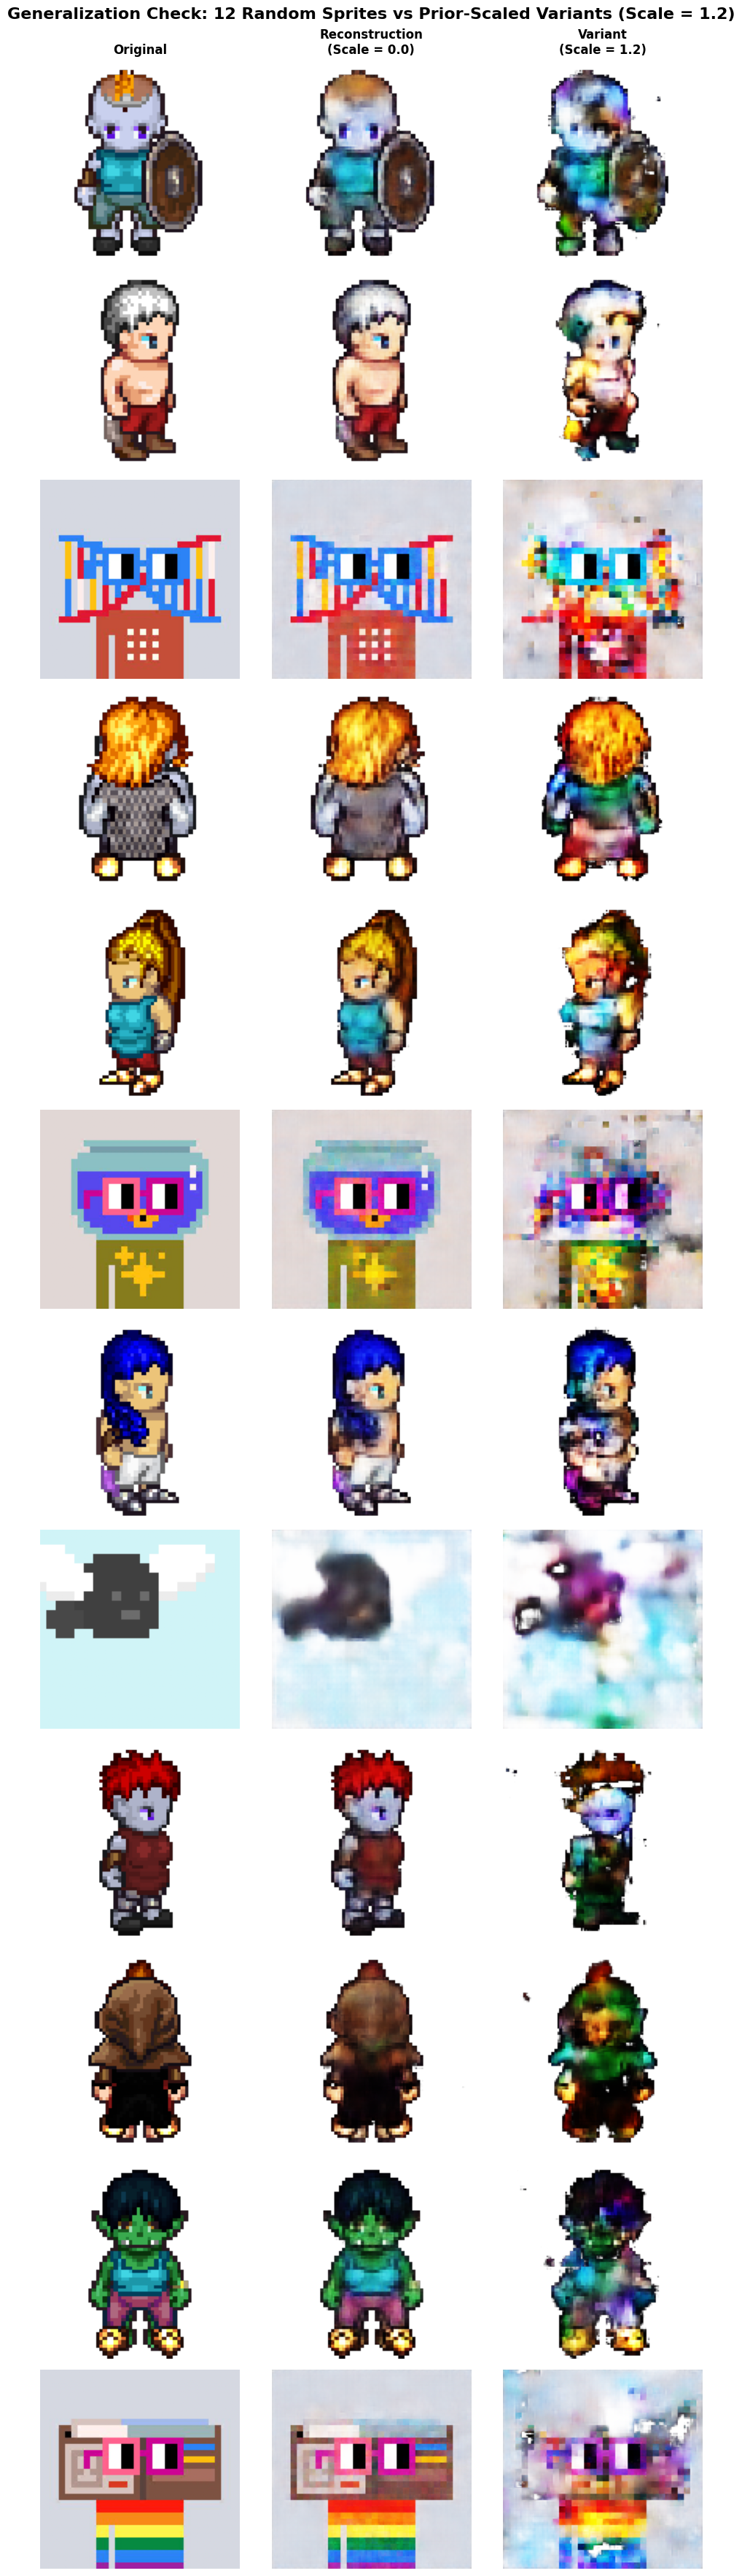

                QUANTITATIVE VAE EVALUATION (12 RANDOM SPRITES)                 
Sprite Idx   | VAE Reconstruction MSE    | VAE Variant MSE (Scale = 1.2)
--------------------------------------------------------------------------------
28           | 0.003874                  | 0.021859
6            | 0.000920                  | 0.022045
70           | 0.000972                  | 0.023451
62           | 0.003804                  | 0.023907
57           | 0.002522                  | 0.019690
35           | 0.001203                  | 0.026891
26           | 0.002772                  | 0.016868
22           | 0.004778                  | 0.020074
108          | 0.001141                  | 0.020539
8            | 0.001808                  | 0.015238
7            | 0.001427                  | 0.015868
23           | 0.000917                  | 0.025925
Average VAE Reconstruction MSE        : 0.002178
Average VAE Variant MSE (Scale = 1.2) : 0.021030
Ratio (Variant MSE / VAE Recon MSE)   : 9.6

In [15]:
print("Running Generalization Check on 12 Random Test Sprites...")

# 1. Select 12 random sprites from the test set
random.seed(42)
random_test_indices = random.sample(range(len(test_originals)), 12)
selected_sprites = test_originals[random_test_indices]

# 2. Encode all 12 sprites to latent space
z_means, z_log_vars, _ = encoder.predict(selected_sprites, batch_size=12, verbose=0)

# 3. Generate variants using the global prior scale fix (scale = 1.2)
scale_gen = 1.2
tf.random.set_seed(42)
epsilons = tf.random.normal(shape=tf.shape(z_means))
z_variants_gen = z_means + (scale_gen * epsilons)

# 4. Decode the variants and reconstructions
decoded_variants = decoder.predict(z_variants_gen, batch_size=12, verbose=0)
decoded_recons = decoder.predict(z_means, batch_size=12, verbose=0)

# 5. Plot 12 rows: Original, Reconstruction, and Variant (Scale = 1.2)
fig, axes = plt.subplots(12, 3, figsize=(10, 36))

for i in range(12):
    # Original
    axes[i, 0].imshow(selected_sprites[i])
    axes[i, 0].axis("off")
    if i == 0:
        axes[i, 0].set_title("Original", weight='bold')
    
    # Reconstruction
    axes[i, 1].imshow(decoded_recons[i])
    axes[i, 1].axis("off")
    if i == 0:
        axes[i, 1].set_title("Reconstruction\n(Scale = 0.0)", weight='bold')
    
    # Variant
    axes[i, 2].imshow(decoded_variants[i])
    axes[i, 2].axis("off")
    if i == 0:
        axes[i, 2].set_title(f"Variant\n(Scale = {scale_gen})", weight='bold')

plt.suptitle(f"Generalization Check: 12 Random Sprites vs Prior-Scaled Variants (Scale = {scale_gen})", fontsize=16, weight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.96)
plt.savefig(os.path.join(BASE_DIR, "variants_comparison_280k.png"), bbox_inches='tight')
plt.show()

# 6. Quantitative Evaluation (Recon MSE vs Variant Change MSE)
vae_mses = [float(np.mean(np.square(selected_sprites[i] - decoded_recons[i]))) for i in range(12)]
variant_mses = [float(np.mean(np.square(decoded_recons[i] - decoded_variants[i]))) for i in range(12)]

print("=" * 80)
print(f"{'QUANTITATIVE VAE EVALUATION (12 RANDOM SPRITES)':^80}")
print("=" * 80)
print(f"{'Sprite Idx':<12} | {'VAE Reconstruction MSE':<25} | {'VAE Variant MSE (Scale = 1.2)'}")
print("-" * 80)
for i in range(12):
    print(f"{random_test_indices[i]:<12} | {vae_mses[i]:<25.6f} | {variant_mses[i]:.6f}")
print("=" * 80)
print(f"Average VAE Reconstruction MSE        : {np.mean(vae_mses):.6f}")
print(f"Average VAE Variant MSE (Scale = 1.2) : {np.mean(variant_mses):.6f}")
print(f"Ratio (Variant MSE / VAE Recon MSE)   : {np.mean(variant_mses)/np.mean(vae_mses):.2f}x")
print("=" * 80)

# Save quantitative results as a JSON
results = {
    "random_test_indices": random_test_indices,
    "vae_reconstruction_mses": vae_mses,
    "vae_variant_mses": variant_mses,
    "average_vae_reconstruction_mse": float(np.mean(vae_mses)),
    "average_vae_variant_mse": float(np.mean(variant_mses)),
    "ratio_variant_to_recon": float(np.mean(variant_mses)/np.mean(vae_mses))
}
with open(os.path.join(BASE_DIR, "vae_evaluation_results.json"), "w") as f:
    json.dump(results, f, indent=2)
print("Saved quantitative evaluation results to JSON.")


## 7. Package Outputs for Download
Run this cell to zip everything up and get a download link.


In [16]:
import shutil
from IPython.display import FileLink

# Zip the directory
zip_path = "/kaggle/working/VAE_280K_Outputs"
shutil.make_archive(zip_path, 'zip', BASE_DIR)

print(f"Created {zip_path}.zip!")
print("Click the link below to download your files:")
FileLink(r'VAE_280K_Outputs.zip')


Created /kaggle/working/VAE_280K_Outputs.zip!
Click the link below to download your files:


/kaggle/working/VAE_280K_Outputs.zip